In [2]:
'''Step 1: ENSO regime classification (Takahashi):
1. Compute monthly SST anomalies over 10°S–10°N, full Pacific basin (lateral coasts), from 1940-2025
2. Extract leading two EOFs/PCs
3. Rotate 45° to get E and C indices: E = (PC1 − PC2)/√2, C = (PC1 + PC2)/√2.
4. Classify each month into ENSO regime states using thresholds on E and C (Takahashi uses |index| > 1σ; you may want to test multiple thresholds).
Also compute RONI and Niño 3.4 for comparison.'''

'Step 1: ENSO regime classification (Takahashi):\n1. Compute monthly SST anomalies over 10°S–10°N, full Pacific basin (lateral coasts), from 1940-2025\n2. Extract leading two EOFs/PCs\n3. Rotate 45° to get E and C indices: E = (PC1 − PC2)/√2, C = (PC1 + PC2)/√2.\n4. Classify each month into ENSO regime states using thresholds on E and C (Takahashi uses |index| > 1σ; you may want to test multiple thresholds).\nAlso compute RONI and Niño 3.4 for comparison.'

In [ ]:
## Takahashi 2011 E/C ENSO classification on ERSST v6

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal, stats
import warnings
warnings.filterwarnings("ignore")

In [4]:
path_origins = ''
name_file = 'sst.mnmean.nc' #ERSST monthly mean 

# f'{path_origins}{name_file}'

SST_PATH      = "/Users/kaijz/Desktop/NOAA/data/sst.mnmean.nc"   # ERSST v6 monthly SST
BASE_PERIOD   = ("1991-01-01", "2026-01-01")  # climatology 1991-2020
LAT_BOUNDS    = (-10, 10)         # 10S - 10N tropical Pacific
LON_BOUNDS    = (120, 290)        # ~western to eastern lateral coasts of Pacific
DETREND       = False             # Toggle linear detrending (see notes)
APPLY_121     = True              # Applying Takahashi's 1-2-1 smoothing filter
TOTAL_PERIOD = ("1940-01-01", "2026-01-01")

In [5]:
ds = xr.open_dataset(SST_PATH).sel(time=slice(*TOTAL_PERIOD))
sst = ds["sst"]

# longitude is from 0-360
print(f"Lon range in file: {float(sst.lon.min())} to {float(sst.lon.max())}")
print(f"Lat range in file: {float(sst.lat.min())} to {float(sst.lat.max())}")
print(f"Time range: {str(sst.time.min().values)[:10]} to {str(sst.time.max().values)[:10]}")


Lon range in file: 0.0 to 358.0
Lat range in file: -88.0 to 88.0
Time range: 1940-01-01 to 2026-01-01


In [6]:
# subset to tropical pacific
sst_tp = sst.sel(
    lat=slice(LAT_BOUNDS[1], LAT_BOUNDS[0]) if sst.lat[0] > sst.lat[-1]
        else slice(LAT_BOUNDS[0], LAT_BOUNDS[1]),
    lon=slice(LON_BOUNDS[0], LON_BOUNDS[1]),
)
print(f"\nSubset shape: {sst_tp.shape} (time, lat, lon)")



Subset shape: (1033, 11, 86) (time, lat, lon)


## Compute monthly climatology and anomalies

In [7]:
# using only 1991- base period for the climatology
sst_base = sst_tp.sel(time=slice(*BASE_PERIOD))
climatology = sst_base.groupby("time.month").mean("time")
print(f"\nClimatology computed over: {BASE_PERIOD}")
print(f"Climatology shape: {climatology.shape}  (month, lat, lon)")

# subtracting climatology from full record
anomalies = sst_tp.groupby("time.month") - climatology
anomalies = anomalies.drop_vars("month")
print(f"Anomalies shape: {anomalies.shape}")



OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



Climatology computed over: ('1991-01-01', '2026-01-01')
Climatology shape: (12, 11, 86)  (month, lat, lon)
Anomalies shape: (1033, 11, 86)


In [8]:
## optional: linear detrending each grid cell

def detrend_along_time(da):
    """Linear detrend each grid cell along the time dim"""
    def _dt(y):
        if np.all(np.isnan(y)):
            return y
        mask = ~np.isnan(y)
        if mask.sum() < 3:
            return y
        x = np.arange(len(y))
        slope, intercept = np.polyfit(x[mask], y[mask], 1)
        return y - (slope * x + intercept)
    return xr.apply_ufunc(
        _dt, da,
        input_core_dims=[["time"]],
        output_core_dims=[["time"]],
        vectorize=True,
    )

if DETREND:
    anomalies = detrend_along_time(anomalies)
    print('Anomalies linearly detrended')
else:
    print('no detrending applied')



no detrending applied


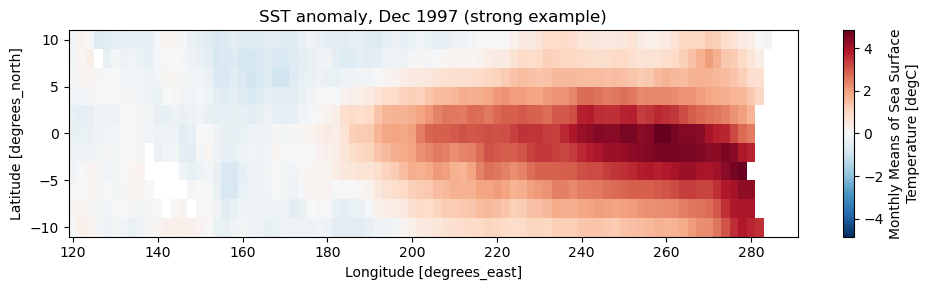

In [9]:
# sample anomaly map

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
anomalies.sel(time="1997-12").squeeze().plot(ax=ax, cmap="RdBu_r", center=0)
ax.set_title("SST anomaly, Dec 1997 (strong example)")
plt.tight_layout()
plt.show()

# EOF Decomposition on base-period anomalies

In [10]:
# base period for EOF computation

anom_base = anomalies.sel(time=slice(*BASE_PERIOD))

# cos area weighting to reflect equal-area variance
weights = np.sqrt(np.cos(np.deg2rad(anom_base.lat)))
anom_base_w = anom_base * weights

# reshaping to (n_time, n_space) for single value decomp
nt, nlat, nlon = anom_base_w.shape
X = anom_base_w.values.reshape(nt, nlat*nlon)

# handle and dro NaN (land) grid cells 
valid_mask = ~np.isnan(X).any(axis=0)
print(f"\nTotal grid cells: {X.shape[1]}, Valid (ocean): {valid_mask.sum()}")
X_valid = X[:, valid_mask]


Total grid cells: 946, Valid (ocean): 884


In [11]:
# SVD-based EOF: X = U S V^T, where V^T columns are EOFs, U*S are PCs
# Subtract time mean (already zero from anomalies, but safe)
X_valid = X_valid - X_valid.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(X_valid, full_matrices=False)

In [12]:
# variance explained

var_explained = (S**2) / (S**2).sum()
print(f"Variance explained by EOF1: {var_explained[0]*100:.1f}%")
print(f"Variance explained by EOF2: {var_explained[1]*100:.1f}%")
print(f"Sum: {(var_explained[0]+var_explained[1])*100:.1f}% compared to")
print(f"Takahashi's: 68% (EOF1) + 14% (EOF2) = 82%")


Variance explained by EOF1: 63.8%
Variance explained by EOF2: 12.4%
Sum: 76.2% compared to
Takahashi's: 68% (EOF1) + 14% (EOF2) = 82%


In [13]:
# extracting first two EOFs (spatial patterns) and PCs (time series)
# reconcstruct full spatial maps (including nan land cells)
eof1_full = np.full(nlat * nlon, np.nan)
eof2_full = np.full(nlat * nlon, np.nan)
eof1_full[valid_mask] = Vt[0]
eof2_full[valid_mask] = Vt[1]
EOF1 = eof1_full.reshape(nlat, nlon)
EOF2 = eof2_full.reshape(nlat, nlon)

In [14]:
# PC's over base period (pre normalization)
PC1_base = U[:, 0] * S[0]
PC2_base = U[:, 1] * S[1]

In [15]:
# Sign convention: positive PC1 should correspond to warm eastern Pacific
# Check by correlating PC1 with mean SST anomaly in Nino 3 region during base period
# If negative, flip both EOF1 and PC1.
EOF1 = -EOF1
PC1_base = -PC1_base
Vt[0] = -Vt[0]
print("EOF1 sign flipped to match El Nino convention.")


EOF1 sign flipped to match El Nino convention.


In [16]:
# For PC2 sign: Takahashi's Figure 3b shows EOF2 with positive loading in
# central Pacific and slightly negative in far east. Check accordingly.
# After EOF1 is fixed, choose PC2 sign so that the 1997/98 event has PC2 < 0
# (since extreme E events lie on the +E axis = PC1>0, PC2<0 in his Fig 2a).
EOF2 = -EOF2
PC2_base = -PC2_base
Vt[1] = -Vt[1]
print("EOF2 sign flipped so 1997-12 has PC2 < 0 (matches Takahashi Fig 2a)")


EOF2 sign flipped so 1997-12 has PC2 < 0 (matches Takahashi Fig 2a)


In [17]:
# normalizing PCs by base-period standard deviation
sigma_pc1 = PC1_base.std()
sigma_pc2 = PC2_base.std()
PC1_base_norm = PC1_base / sigma_pc1
PC2_base_norm = PC2_base / sigma_pc2

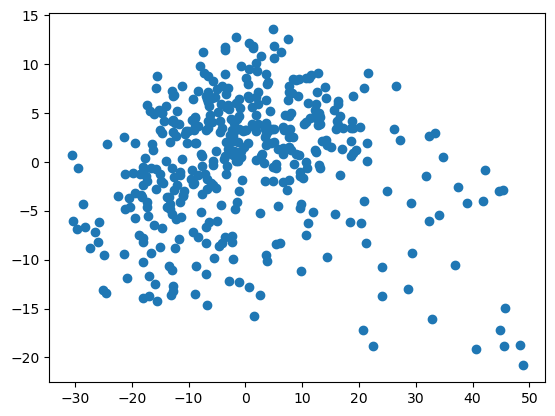

In [18]:
plt.scatter(PC1_base, PC2_base)

# Projecting full record onto base-period EOFs

In [19]:
anom_w_full = anomalies * weights
X_full = anom_w_full.values.reshape(anomalies.shape[0], nlat * nlon)
X_full_valid = X_full[:, valid_mask]
X_full_valid = X_full_valid - X_valid.mean(axis=0, keepdims=True)  # use base-period mean

# Projection: PC_k(t) = X_full_valid @ EOF_k
PC1_full = X_full_valid @ Vt[0]
PC2_full = X_full_valid @ Vt[1]

# Normalize by base-period sigma
PC1 = PC1_full / sigma_pc1
PC2 = PC2_full / sigma_pc2

## applying 1-2-1
kernel = np.array([0.25, 0.5, 0.25])
PC1 = np.convolve(PC1, kernel, mode="same")
PC2 = np.convolve(PC2, kernel, mode="same")
print("1-2-1 smoothing applied to PCs")

pc_ds = xr.Dataset(
    {"PC1": ("time", PC1), "PC2": ("time", PC2)},
    coords={"time": anomalies.time},
)

1-2-1 smoothing applied to PCs


## 45 degree rotation

In [20]:
E = (PC1 - PC2) / np.sqrt(2)
C = (PC1 + PC2) / np.sqrt(2)
pc_ds["E"] = ("time", E)
pc_ds["C"] = ("time", C)

# Sanity checks

In [21]:
# Check 1: E and C should be (nearly) uncorrelated
r_EC = np.corrcoef(E, C)[0, 1]
print(f"\n1. Correlation E vs C: {r_EC:.4f}  (should be near 0)")

# Check 2: PC1 and PC2 uncorrelated over base period
r_PC = np.corrcoef(PC1_base_norm, PC2_base_norm)[0, 1]
print(f"2. Correlation PC1 vs PC2 over base period: {r_PC:.4f}  (should be ~0)")

# Check 3: E correlates strongly with Nino 1+2
nino12 = sst_tp.sel(
    lat=slice(0, -10) if sst_tp.lat[0]>sst_tp.lat[-1] else slice(-10, 0),
    lon=slice(270, 280),
).groupby("time.month").mean("time")
# Compute Nino 1+2 anomalies
nino12_clim = sst_tp.sel(time=slice(*BASE_PERIOD),
                        lat=slice(0,-10) if sst_tp.lat[0]>sst_tp.lat[-1] else slice(-10,0),
                        lon=slice(270, 280)).groupby("time.month").mean("time")
nino12_anom_full = sst_tp.sel(
    lat=slice(0, -10) if sst_tp.lat[0]>sst_tp.lat[-1] else slice(-10, 0),
    lon=slice(270, 280),
).groupby("time.month") - nino12_clim
nino12_ts = nino12_anom_full.mean(["lat", "lon"]).values
r_E_nino12 = np.corrcoef(E, nino12_ts)[0, 1]
print(f"3. Correlation E vs Nino 1+2: {r_E_nino12:.4f}  (Takahashi: 0.94)")

# Check 4: C correlates strongly with Nino 4
nino4_clim = sst_tp.sel(time=slice(*BASE_PERIOD),
                       lat=slice(5,-5) if sst_tp.lat[0]>sst_tp.lat[-1] else slice(-5,5),
                       lon=slice(160, 210)).groupby("time.month").mean("time")
nino4_anom = sst_tp.sel(
    lat=slice(5, -5) if sst_tp.lat[0]>sst_tp.lat[-1] else slice(-5, 5),
    lon=slice(160, 210),
).groupby("time.month") - nino4_clim
nino4_ts = nino4_anom.mean(["lat", "lon"]).values
r_C_nino4 = np.corrcoef(C, nino4_ts)[0, 1]
print(f"4. Correlation C vs Nino 4: {r_C_nino4:.4f}  (Takahashi: 0.98)")




1. Correlation E vs C: 0.1023  (should be near 0)
2. Correlation PC1 vs PC2 over base period: -0.0000  (should be ~0)
3. Correlation E vs Nino 1+2: 0.9150  (Takahashi: 0.94)
4. Correlation C vs Nino 4: 0.9502  (Takahashi: 0.98)


In [22]:
# Check 5: Skewness of E and C
print(f"5. Skewness E: {stats.skew(E):.2f}  (Takahashi: +1.78, positive expected)")
print(f"   Skewness C: {stats.skew(C):.2f}  (Takahashi: -0.62, negative expected)")

# Check 6: Check that 1982-83 and 1997-98 have large positive E
for date in ["1983-01", "1997-12", "1998-01", "2016-01"]:
    idx = np.where(pc_ds.time.dt.strftime("%Y-%m").values == date)[0]
    if len(idx):
        print(f"   {date}: E={E[idx[0]]:+.2f}, C={C[idx[0]]:+.2f}")


5. Skewness E: 1.35  (Takahashi: +1.78, positive expected)
   Skewness C: -0.23  (Takahashi: -0.62, negative expected)
   1983-01: E=+3.42, C=+0.33
   1997-12: E=+4.26, C=+0.24
   1998-01: E=+3.72, C=+0.45
   2016-01: E=+1.95, C=+1.86


# plots

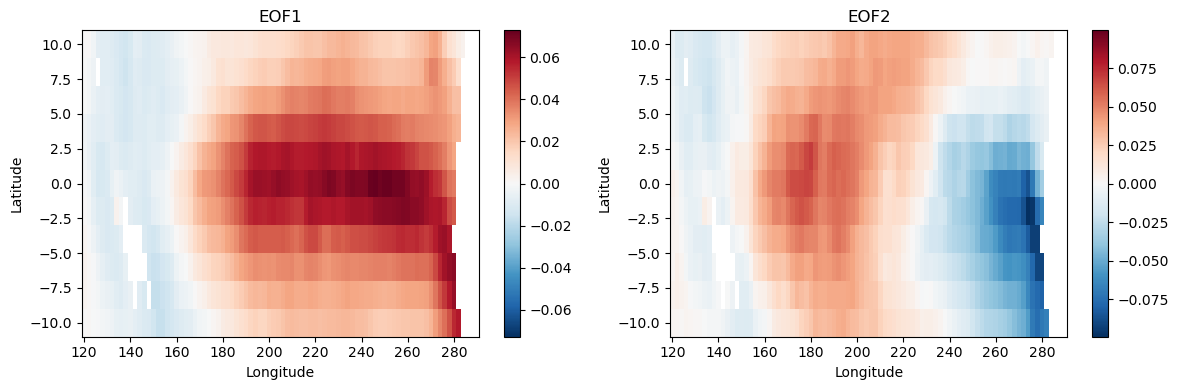

In [24]:
# Plot 1: EOF1 and EOF2 spatial patterns
# compare to Takahashi Fig 3a/b

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, eof, title in zip(axes, [EOF1, EOF2], ["EOF1", "EOF2"]):
    im = ax.pcolormesh(anom_base.lon, anom_base.lat, eof,
                       cmap="RdBu_r",
                       vmin=-np.nanmax(np.abs(eof)),
                       vmax=np.nanmax(np.abs(eof)))
    ax.set_title(title)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

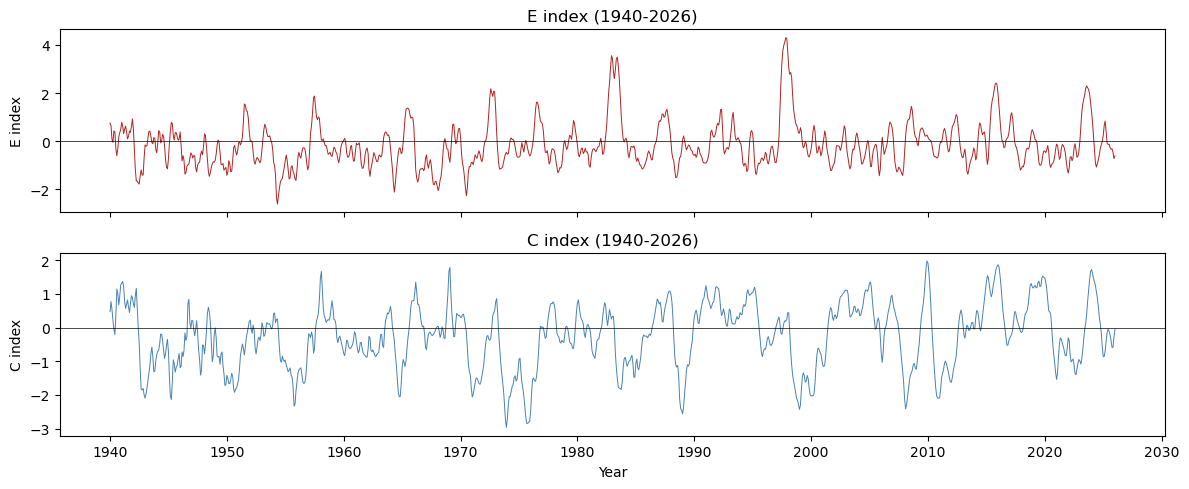

In [ ]:
# Plot 2: E and C time series
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(pc_ds.time, E, color="firebrick", lw=0.7)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("E index"); axes[0].set_title("E index (1940-2026)")
axes[1].plot(pc_ds.time, C, color="steelblue", lw=0.7)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_ylabel("C index"); axes[1].set_xlabel("Year")
axes[1].set_title("C index (1940-2026)")
plt.tight_layout(); plt.show()

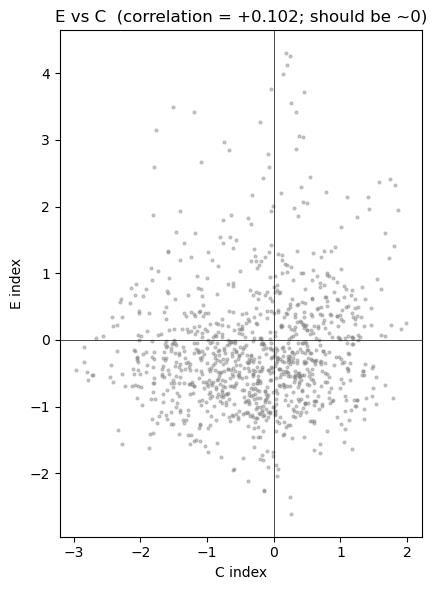

In [ ]:
# Plot 3: E vs C scatter with uncorrelated axes
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(C, E, s=4, alpha=0.4, color="gray")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("C index"); ax.set_ylabel("E index")
ax.set_title(f"E vs C  (correlation = {r_EC:+.3f}; should be ~0)")
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

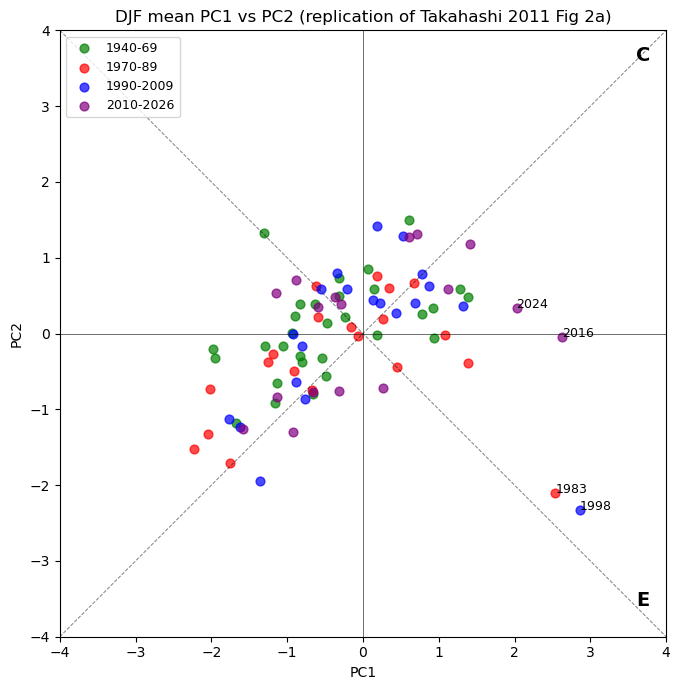

In [25]:
# Plot 4: Takahashi Figure 2a replication
# DJF mean PC1 vs PC2, color-coded by decade
months = pc_ds.time.dt.month.values
years = pc_ds.time.dt.year.values
djf_mask = np.isin(months, [12, 1, 2])
# Assign each DJF month to its winter year (e.g. Dec 1997 + Jan/Feb 1998 -> "1998")
winter_year = np.where(months == 12, years + 1, years)

pc1_djf, pc2_djf, wy_djf = [], [], []
for wy in np.unique(winter_year[djf_mask]):
    mask = (winter_year == wy) & djf_mask
    if mask.sum() >= 2:
        pc1_djf.append(PC1[mask].mean())
        pc2_djf.append(PC2[mask].mean())
        wy_djf.append(wy)
pc1_djf = np.array(pc1_djf); pc2_djf = np.array(pc2_djf); wy_djf = np.array(wy_djf)

fig, ax = plt.subplots(figsize=(7, 7))
colors = ["green", "red", "blue", "purple"]
labels = ["1940-69", "1970-89", "1990-2009", "2010-2026"]
bins = [(1940, 1969), (1970, 1989), (1990, 2009), (2010, 2030)]
for (y0, y1), c, lab in zip(bins, colors, labels):
    m = (wy_djf >= y0) & (wy_djf <= y1)
    ax.scatter(pc1_djf[m], pc2_djf[m], c=c, label=lab, s=40, alpha=0.7)


# Draw E and C axes (45-degree rotation)
lim = 4
ax.plot([-lim, lim], [lim, -lim], "k--", lw=0.7, alpha=0.5)  # E axis
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.7, alpha=0.5)  # C axis
ax.text(lim*0.9, -lim*0.9, "E", fontsize=14, fontweight="bold")
ax.text(lim*0.9, lim*0.9, "C", fontsize=14, fontweight="bold")

# Label extreme events
for wy, p1, p2 in zip(wy_djf, pc1_djf, pc2_djf):
    if p1 > 2 or wy in [1983, 1998, 2016]:
        ax.annotate(str(wy), (p1, p2), fontsize=9)

ax.axhline(0, color="k", lw=0.4); ax.axvline(0, color="k", lw=0.4)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_title("DJF mean PC1 vs PC2 (replication of Takahashi 2011 Fig 2a)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

In [27]:
ds

<xarray.Dataset> Size: 66MB
Dimensions:    (time: 1033, nbnds: 2, lat: 89, lon: 180)
Coordinates:
  * time       (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2026-01-01
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 17kB ...
    sst        (time, lat, lon) float32 66MB ...
Attributes: (12/39)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    product_version:           Version 6
    history:                   created 01/16/2025 by PSL using NCEI ERSST V6 ...
    References:                https://www.ncdc.noaa.gov/data-access/marineoc...
    summary:                   ERSSTv6 is developped based on v5, by replacin...
    comments:                  SSTs were observed by conventional thermometer...
    platform:                  Ship and Buoy SSTs from ICOADS R3.0.2 and Argo...

In [64]:
time = ds['time'].to_pandas()

In [66]:
df = pd.DataFrame()
df['year'] = time.dt.year
df['month'] = time.dt.month
df['E_index'] = E
df['C_index'] = C
df.reset_index(drop=True)

,year,month,E_index,C_index
0,1940,1,0.757927,0.473475
1,1940,2,0.647213,0.772481
2,1940,3,0.089166,0.546854
3,1940,4,-0.042599,0.215834
4,1940,5,0.427767,-0.045976
...,...,...,...,...
1028,2025,9,-0.330321,-0.377289
1029,2025,10,-0.308912,-0.588954
1030,2025,11,-0.464628,-0.584708
1031,2025,12,-0.714990,-0.284156


In [ ]:
df.to_csv('/Users/kaijz/Desktop/NOAA/data/ecindex_ersstv6.csv', index=False)